In [29]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats

# ---------- 常数 ----------
cp = 1004.0
Lv = 2.5e6
Ck_Cd = 1.0

def es(T):
    TC = T - 273.15
    return 6.112 * np.exp(17.67 * TC / (TC + 243.5))

def qstar(T, p):
    e = es(T)
    return 0.622 * e / (p - 0.378 * e)

# ---------- 1. 读取多年份 ----------
def load_year(year):
    # 定义区域范围
    lat_range = slice(60, 0)      # 60N → 0N
    lon_range = slice(100, 180)   # 100E → 180E

    ps = xr.open_dataset(f"D:/data/era5/daily2.5/mean_sea_level_pressure/slp_{year}.nc")["msl"].sel(latitude=lat_range, longitude=lon_range) / 100.0
    Ts = xr.open_dataset(f"D:/data/era5/daily2.5/sea_surface_temperature/sst_{year}.nc")["sst"].sel(latitude=lat_range, longitude=lon_range)
    t1 = xr.open_dataset(f"D:/data/era5/daily2.5/temperature/t_700_850_925_1000_{year}.nc")["t"].sel(latitude=lat_range, longitude=lon_range)
    t2 = xr.open_dataset(f"D:/data/era5/daily2.5/temperature_3456/t_300_400_500_600_{year}.nc")["t"].sel(latitude=lat_range, longitude=lon_range)
    q1 = xr.open_dataset(f"D:/data/era5/daily2.5/specific_humidity/q_700_850_925_1000_{year}.nc")["q"].sel(latitude=lat_range, longitude=lon_range)

    Ta = t1.sel(pressure_level=1000)
    qa = q1.sel(pressure_level=1000)
    To = t2.sel(pressure_level=300)

    return ps, Ts, Ta, qa, To


def compute_PI(ps, Ts, Ta, qa, To):
    q_s_star = qstar(Ts, ps)
    delta_k = cp * (Ts - Ta) + Lv * (q_s_star - qa)
    delta_k = xr.where(delta_k > 0, delta_k, 0)
    factor = Ck_Cd * (Ts - To) / To
    factor = xr.where(factor > 0, factor, 0)
    return np.sqrt(factor * delta_k)



# def compute_PI(ps, Ts, Ta, qa, To):
#     """
#     计算 Emanuel (1995) 潜在强度（PI, m/s）
#     输入：
#       ps: 海平面气压 (hPa)
#       Ts: 海表温度 (K)
#       Ta: 近海面空气温度 (K)
#       qa: 近海面比湿 (kg/kg)
#       To: 对流层顶温度 (K)
#     """
#     q_s_star = qstar(Ts, ps)  # 饱和比湿
#     k_star = cp * Ts + Lv * q_s_star
#     k = cp * Ta + Lv * qa
#     delta_k = xr.where(k_star > k, k_star - k, 0)

#     eta = (Ts - To) / To  # 热效率项
#     eta = xr.where(eta > 0, eta, 0)

#     PI_squared = Ck_Cd * eta * delta_k
#     PI = np.sqrt(PI_squared)

#     return PI


In [30]:
# ---------- 2. 计算各年份平均 ----------
years1 = range(1982, 1999)
years2 = range(1999, 2024)

def mean_period(years):
    PI_list = []
    for y in years:
        ps, Ts, Ta, qa, To = load_year(y)
        PI = compute_PI(ps, Ts, Ta, qa, To)
        PI_list.append(PI)
    PI_all = xr.concat(PI_list, dim="time")
    return PI_all.mean("time")


In [31]:
PI_early = mean_period(years1)
PI_late = mean_period(years2)
p1=np.mean(PI_early, axis=0)
p2=np.mean(PI_late, axis=0)
p3=p2-p1

In [32]:
tval, pval = stats.ttest_ind(PI_late, PI_early, axis=0, equal_var=False, nan_policy='omit')
# 显著性掩膜（p<0.05）
sig_mask = (pval < 0.05)

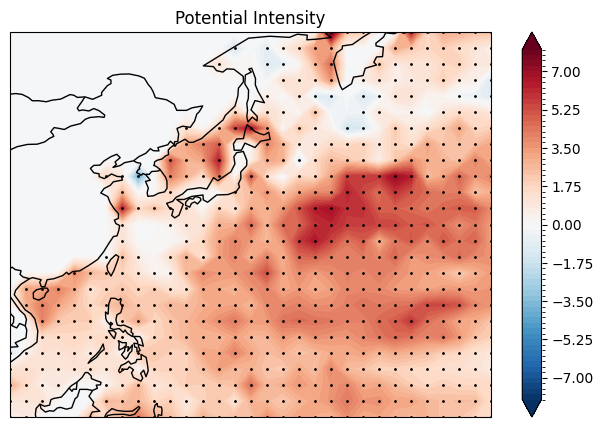

In [33]:
# ---------- 4. 绘图 ----------
plt.figure(figsize=(8,5))
proj = ccrs.PlateCarree()
ax = plt.axes(projection=proj)

# 主图：两时期差值
levels = np.linspace(-8, 8, 65)
cs = p3.plot.contourf(ax=ax, transform=proj, levels=levels,
                      cmap='RdBu_r', extend='both')

# 添加显著性点（黑色小点）
lon2d, lat2d = np.meshgrid(p3.longitude, p3.latitude)
ax.scatter(lon2d[sig_mask], lat2d[sig_mask], color='black', s=1, transform=ccrs.PlateCarree())
# 版面美化
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.set_extent([105, 180, 0, 60], crs=proj)
plt.title("Potential Intensity")
# plt.colorbar(cs, ax=ax, orientation="horizontal", pad=0.1, label="m/s")
plt.show()

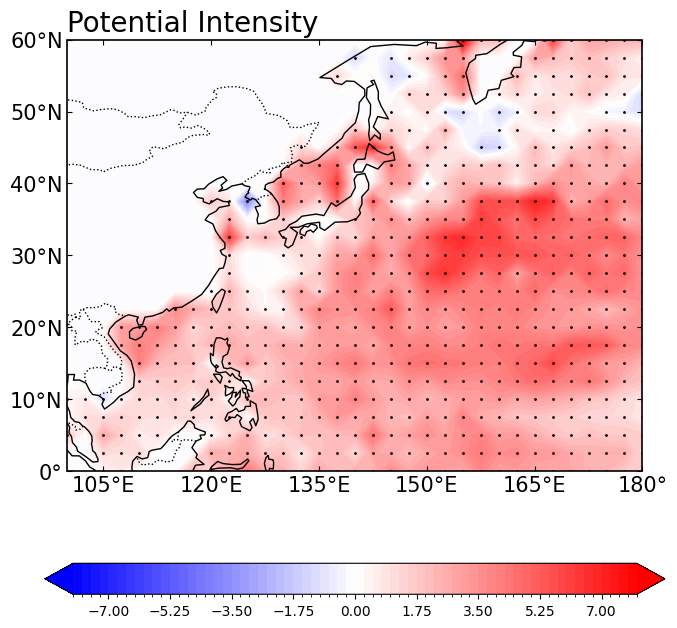

In [34]:
cmap_value=plt.get_cmap('bwr') 
import cartopy.mpl.ticker as cticker
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 15) 
ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 15) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

levels = np.linspace(-8, 8, 65)
cs = p3.plot.contourf(ax=ax, transform=proj, levels=levels,cmap=cmap_value, extend='both',add_colorbar=False,add_labels=False)

# 添加显著性点（黑色小点）
lon2d, lat2d = np.meshgrid(p3.longitude, p3.latitude)
ax.scatter(lon2d[sig_mask], lat2d[sig_mask], color='black', s=1, transform=ccrs.PlateCarree())

cbar = plt.colorbar(cs, ax=ax, orientation='horizontal', shrink=0.8)
ax.set_title('Potential Intensity', loc='left', fontsize=20)
plt.savefig("PI.pdf",transparent = True)
plt.show()

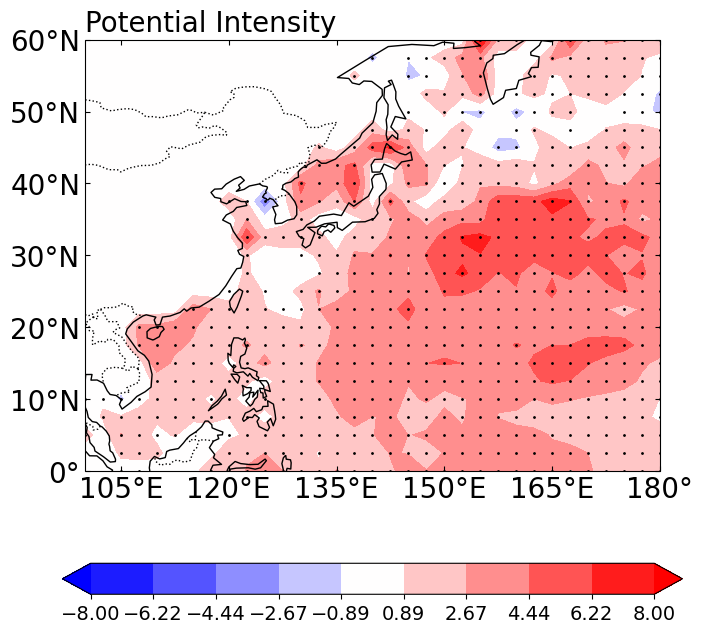

In [37]:
lat=p3['latitude']
lon=p3['longitude']
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100,180, 0,60], crs=ccrs.PlateCarree())

# 绘制网格线
# cbar2.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 20) 
ax.set_yticklabels(np.arange(0, 61, 10),fontsize = 20) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')


# Create contour plot
contour = ax.contourf(lon, lat, p3, cmap=cmap_value, levels=np.linspace(-8,8, 10), extend='both',transform=ccrs.PlateCarree())

# 在显著性通过95%的地方打黑点

ax.scatter(lon2d[sig_mask], lat2d[sig_mask], color='black', s=1, transform=ccrs.PlateCarree())

cbar = plt.colorbar(contour, ax=ax, orientation='horizontal',shrink=0.8)
cbar.ax.tick_params(labelsize=14)


ax.set_title('Potential Intensity', loc='left', fontsize=20)
plt.savefig("PI.pdf",transparent = True)
plt.show()

In [38]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
import os

# ============= 1. 常数定义 =============
cp = 1004.0
Lv = 2.5e6
Ck_Cd = 1.0
RdRv = 0.622

# 路径
datadir = "D:/data/era5/daily2.5/"
# （根据你原始文件夹结构）
ps_dir = f"{datadir}/mean_sea_level_pressure/"
sst_dir = f"{datadir}/sea_surface_temperature/"
t_low_dir = f"{datadir}/temperature/"
t_high_dir = f"{datadir}/temperature_3456/"
q_dir = f"{datadir}/specific_humidity/"

# ============= 2. 辅助函数 =============
def es(T):
    """饱和水汽压 (hPa)"""
    Tc = T - 273.15
    return 6.112 * np.exp(17.67 * Tc / (Tc + 243.5))

def qstar(T, p):
    """饱和比湿 (kg/kg)"""
    e = es(T)
    return 0.622 * e / (p - 0.378 * e)

def load_year(year):
    """读取单年数据"""
    lat_range = slice(60, 0)      # 60N → 0N
    lon_range = slice(100, 180)   # 100E → 180E

    ps = xr.open_dataset(f"{ps_dir}slp_{year}.nc")["msl"].sel(latitude=lat_range, longitude=lon_range) / 100.0
    Ts = xr.open_dataset(f"{sst_dir}sst_{year}.nc")["sst"].sel(latitude=lat_range, longitude=lon_range)
    t1 = xr.open_dataset(f"{t_low_dir}t_700_850_925_1000_{year}.nc")["t"].sel(latitude=lat_range, longitude=lon_range)
    t2 = xr.open_dataset(f"{t_high_dir}t_300_400_500_600_{year}.nc")["t"].sel(latitude=lat_range, longitude=lon_range)
    q1 = xr.open_dataset(f"{q_dir}q_700_850_925_1000_{year}.nc")["q"].sel(latitude=lat_range, longitude=lon_range)

    Ta = t1.sel(pressure_level=1000)
    qa = q1.sel(pressure_level=1000)
    To = t2.sel(pressure_level=300)

    return ps, Ts, Ta, qa, To

def compute_PI(ps, Ts, Ta, qa, To):
    """计算 Emanuel (1995) 潜在强度（m/s）"""
    q_s_star = qstar(Ts, ps)
    k_star = cp * Ts + Lv * q_s_star
    k_env = cp * Ta + Lv * qa
    delta_k = xr.where(k_star > k_env, k_star - k_env, 0)
    eta = (Ts - To) / To
    eta = xr.where(eta > 0, eta, 0)
    PI2 = Ck_Cd * eta * delta_k
    PI = np.sqrt(np.maximum(PI2, 0))
    return PI

# ============= 3. 计算两时期平均 =============
years1 = range(1982, 1999)  # Period I
years2 = range(1999, 2024)  # Period II

def mean_period(years):
    PI_list = []
    for y in years:
        print(f"Processing year {y} ...")
        ps, Ts, Ta, qa, To = load_year(y)
        PI = compute_PI(ps, Ts, Ta, qa, To)
        PI_list.append(PI)
    PI_all = xr.concat(PI_list, dim="time")
    return PI_all

# 计算两时期的 PI 数据
PI_early = mean_period(years1)
PI_late = mean_period(years2)

# 计算平均与差异
p1 = PI_early.mean("time")
p2 = PI_late.mean("time")
p1=p1.mean(dim="valid_time")
p2=p2.mean(dim="valid_time")
p3=p2-p1

# ============= 4. 显著性检验 =============
# 对应格点逐点 t 检验
tval, pval = stats.ttest_ind(PI_late, PI_early, axis=0, equal_var=False, nan_policy='omit')
sig_mask = (pval < 0.05)

# ============= 5. 绘图 =============
plt.figure(figsize=(9, 5))
proj = ccrs.PlateCarree()
ax = plt.axes(projection=proj)

# 差值填色图
levels = np.linspace(-8, 8, 65)
cs = p3.plot.contourf(ax=ax, transform=proj, levels=levels,
                      cmap='RdBu_r', extend='both', add_colorbar=False)

# 添加显著性点
lon2d, lat2d = np.meshgrid(p3.longitude, p3.latitude)
ax.scatter(lon2d[sig_mask], lat2d[sig_mask],
           color='black', s=2, transform=ccrs.PlateCarree(), alpha=0.6)

# 地图要素
ax.coastlines(resolution='50m')
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_extent([105, 180, 0, 60], crs=proj)
ax.set_title("Difference of Potential Intensity (Late - Early)", fontsize=12)

# 色标
cbar = plt.colorbar(cs, ax=ax, orientation="horizontal", pad=0.08, aspect=40)
cbar.set_label("PI difference (m/s)")

plt.tight_layout()
plt.show()


Processing year 1982 ...
Processing year 1983 ...
Processing year 1984 ...
Processing year 1985 ...
Processing year 1986 ...
Processing year 1987 ...
Processing year 1988 ...
Processing year 1989 ...
Processing year 1990 ...
Processing year 1991 ...
Processing year 1992 ...
Processing year 1993 ...
Processing year 1994 ...
Processing year 1995 ...
Processing year 1996 ...
Processing year 1997 ...
Processing year 1998 ...
Processing year 1999 ...
Processing year 2000 ...
Processing year 2001 ...
Processing year 2002 ...
Processing year 2003 ...
Processing year 2004 ...
Processing year 2005 ...
Processing year 2006 ...
Processing year 2007 ...
Processing year 2008 ...
Processing year 2009 ...
Processing year 2010 ...
Processing year 2011 ...
Processing year 2012 ...
Processing year 2013 ...
Processing year 2014 ...
Processing year 2015 ...
Processing year 2016 ...
Processing year 2017 ...
Processing year 2018 ...
Processing year 2019 ...
Processing year 2020 ...
Processing year 2021 ...


ValueError: Array shapes are incompatible for broadcasting.

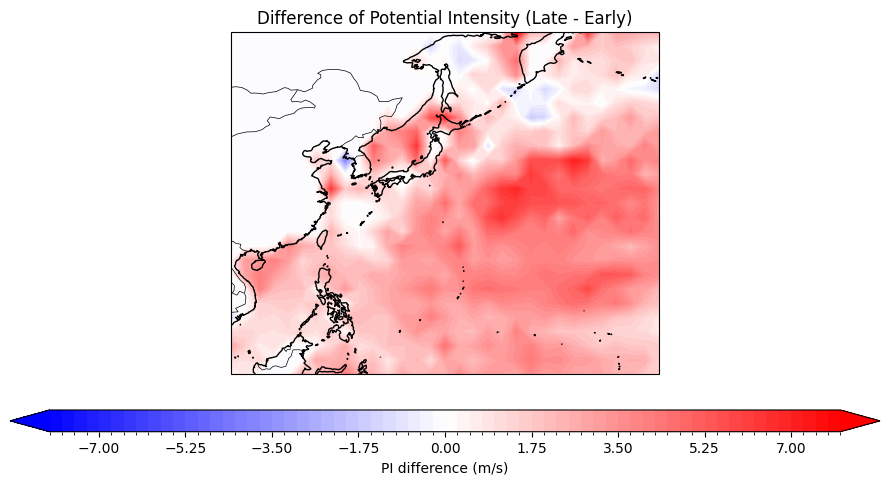

In [28]:
# ============= 5. 绘图 =============
plt.figure(figsize=(9, 5))
proj = ccrs.PlateCarree()
ax = plt.axes(projection=proj)

# 差值填色图
levels = np.linspace(-8, 8, 65)
cs = p3.plot.contourf(ax=ax, transform=proj, levels=levels,
                      cmap=cmap_value, extend='both', add_colorbar=False)

# 添加显著性点
lon2d, lat2d = np.meshgrid(p3.longitude, p3.latitude)
ax.scatter(lon2d[sig_mask], lat2d[sig_mask],
           color='black', s=2, transform=ccrs.PlateCarree(), alpha=0.6)

# 地图要素
ax.coastlines(resolution='50m')
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_extent([105, 180, 0, 60], crs=proj)
ax.set_title("Difference of Potential Intensity (Late - Early)", fontsize=12)

# 色标
cbar = plt.colorbar(cs, ax=ax, orientation="horizontal", pad=0.08, aspect=40)
cbar.set_label("PI difference (m/s)")

plt.tight_layout()
plt.show()
